In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 选取最后几个Jet，在Jer=162.0的情况下全部运行100次
- + 在所谓的最优参数下，即Jet=78.2，Jer=162.0时运行1000次，依然存在particular100中
- a=8.4 Jrt=-0.6 快慢纺锤更大的区别
- 6.22汇报时的参数全探索基础上 修改scale2=0.0005 无噪声 初始值随机

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 1000              # 每个参数组合运行的次数
c2tsc = 0.8              # 固定 c2tsc
scale2 = 0.0005          # 固定 scale2
a = 8.4                  # 固定 a
Jrt = -0.6               # 固定 Jrt

Jet_max = 1.98 * 75   # 148.5
Jer_max = 3.24 * 50   # 162

# 对数间隔：小值变化更精细
Jet_list = np.logspace(np.log10(6.5), np.log10(Jet_max), 40)  # 从 0.1 开始，避免 0
#Jet_list = np.logspace(np.log10(0.1), np.log10(Jet_max), 10)  # 从 0.1 开始，避免 0
#Jet_list = np.insert(Jet_list, 0, 0)  # 如果想包含 0，手动加上
Jet_list = Jet_list[-9:-8]
#Jet_list = Jet_list[-9::2]

Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 10)
Jer_list = Jer_list[-1:]  # 只取最后一个值
#Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 5)
#Jer_list = np.insert(Jer_list, 0, 0)

print(f"Jet 范围: {Jet_list}")
print(f"Jer 范围: {Jer_list}")
print(f"总参数组合数: {len(Jet_list) * len(Jer_list)}")
print(f"总运行次数: {len(Jet_list) * len(Jer_list) * n_runs}")



Jet 范围: [78.16198172]
Jer 范围: [162.]
总参数组合数: 1
总运行次数: 1000


In [3]:

# 创建保存目录
DATA_DIR = "data/raw_data_explore_Jet_Jer_scale0x0005_Jrta_particular100"
os.makedirs(DATA_DIR, exist_ok=True)

# 统计已完成文件，支持断点续跑
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"已存在 {len(existing_files)} 个文件，将跳过它们")

total_tasks = 100
completed = 0
skipped = 0

for Jet_val in Jet_list:
    for Jer_val in Jer_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_Jet_{Jet_val:.4f}_Jer_{Jer_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(DATA_DIR, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                skipped += 1
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2
            params["Jet"] = Jet_val
            params["Jer"] = Jer_val

            # 修改 a 和 Jrt
            params["VT_t"] = 26 -a#26 -9
            params["VT_r"] = 23 -a#23
            params["VB_t"] = 15 -a#15
            params["VB_r"] = 15 -a#15
            params["Jrt"] = Jrt # -0.5
                        
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "Jet": Jet_val,
                "Jer": Jer_val,
                "seed": seed
            })
            completed += 1
            print(f"Saved: Jet={Jet_val:.4f}, Jer={Jer_val:.4f}, seed={seed} (已完成 {completed})")

print(f"\n完成！新运行: {completed}, 跳过: {skipped}")
print(f"数据保存在: {DATA_DIR}")

已存在 500 个文件，将跳过它们
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_1.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_2.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_3.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_4.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_5.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_6.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_7.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_8.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_9.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_10.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_11.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_12.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_13.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_14.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_78.1

In [4]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


#### 对纺锤波进行细分，看是否对称

In [ ]:
import numpy as np
import pandas as pd
import yasa
import glob
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 参数设置 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}

# 数据路径
DATA_DIR = "data/raw_data_explore_Jet_Jer_scale0x0005_Jrta_particular100"

# 目标参数
target_Jet = 78.2
target_Jer = 162.0

# 容差（浮点数比较）
tolerance = 0.5

def get_phase(signal, filter_args, pad=None):
    """返回相位（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, slow_phase, V_t=None):
    """处理纺锤波检测结果，包含上升/下降阶段分析"""
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        overall_amplitude = row["Amplitude"]
        
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        
        # ===== start→peak 和 peak→end 分析 =====
        rise_time = peak_time - start_time
        fall_time = end_time - peak_time
        
        start_segment = V_t[start_idx_sample:peak_idx_sample] if peak_idx_sample > start_idx_sample else np.array([0])
        end_segment = V_t[peak_idx_sample:end_idx_sample] if end_idx_sample > peak_idx_sample else np.array([0])
        
        if len(start_segment) >= 2:
            rise_amp = np.max(start_segment) - np.min(start_segment)
            rise_slope = rise_amp / rise_time if rise_time > 0 else 0
        else:
            rise_amp = 0.0
            rise_slope = 0.0
        
        if len(end_segment) >= 2:
            fall_amp = np.max(end_segment) - np.min(end_segment)
            fall_slope = fall_amp / fall_time if fall_time > 0 else 0
        else:
            fall_amp = 0.0
            fall_slope = 0.0
        
        # 对称性指标
        time_ratio = rise_time / fall_time if fall_time > 0 else np.nan
        amp_ratio = rise_amp / fall_amp if fall_amp > 0 else np.nan
        slope_ratio = rise_slope / fall_slope if fall_slope > 0 else np.nan
        
        time_asymmetry = abs(rise_time - fall_time) / (rise_time + fall_time) if (rise_time + fall_time) > 0 else np.nan
        amp_asymmetry = abs(rise_amp - fall_amp) / (rise_amp + fall_amp) if (rise_amp + fall_amp) > 0 else np.nan
        slope_asymmetry = abs(rise_slope - fall_slope) / (rise_slope + fall_slope) if (rise_slope + fall_slope) > 0 else np.nan
        
        phase_start = slow_phase[start_idx]
        phase_peak = slow_phase[peak_idx]
        phase_end = slow_phase[end_idx]
        
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": overall_amplitude,
            # 上升阶段
            "rise_time": rise_time,
            "rise_amp": rise_amp,
            "rise_slope": rise_slope,
            # 下降阶段
            "fall_time": fall_time,
            "fall_amp": fall_amp,
            "fall_slope": fall_slope,
            # 对称性
            "time_ratio": time_ratio,
            "amp_ratio": amp_ratio,
            "slope_ratio": slope_ratio,
            "time_asymmetry": time_asymmetry,
            "amp_asymmetry": amp_asymmetry,
            "slope_asymmetry": slope_asymmetry,
            # 相位
            "phase_at_start": phase_start,
            "phase_at_peak": phase_peak,
            "phase_at_end": phase_end,
        })
    return results

# ========== 查找目标文件 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")

# 筛选目标参数的文件
matched_files = []
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 解析参数
    Jet_idx = parts.index('Jet') + 1 if 'Jet' in parts else -1
    Jer_idx = parts.index('Jer') + 1 if 'Jer' in parts else -1
    
    if Jet_idx == -1 or Jer_idx == -1:
        continue
    
    Jet_val = float(parts[Jet_idx])
    Jer_val = float(parts[Jer_idx])
    
    if abs(Jet_val - target_Jet) < tolerance and abs(Jer_val - target_Jer) < tolerance:
        matched_files.append((Jet_val, Jer_val, file_path))

print(f"找到 {len(matched_files)} 个匹配文件:")
for Jet_val, Jer_val, f in matched_files:
    print(f"  Jet={Jet_val:.4f}, Jer={Jer_val:.4f}, {os.path.basename(f)}")

if len(matched_files) == 0:
    print("未找到匹配文件，请检查目标参数")
    exit()

# ========== 处理所有匹配的文件 ==========
all_spindles = []

for Jet_val, Jer_val, file_path in matched_files:
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    # 从文件名中提取 seed
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    seed = int(parts[seed_idx]) if seed_idx != -1 else -1
    
    print(f"\nProcessing: Jet={Jet_val:.4f}, Jer={Jer_val:.4f}, seed={seed}")
    
    # 时间边界
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    # 计算慢波相位
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase = get_phase(aln_sig, filter_args=SW, pad=0.0)
    
    params = {
        "Jet": Jet_val,
        "Jer": Jer_val,
        "seed": seed,
    }
    
    # 检测纺锤波
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, slow_phase, V_t))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, slow_phase, V_t))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")


找到 1400 个文件
找到 1000 个匹配文件:
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_1.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_10.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_100.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_1000.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_101.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_102.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_103.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_104.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_105.npy
  Jet=78.1620, Jer=162.0000, c2tsc_0.8000_scale2_0.0005_Jet_78.1620_Jer_162.0000_seed_106.npy
  Jet=78.1620, Jer=162.0000, c2tsc_

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=1, 慢=8

Processing: Jet=78.1620, Jer=162.0000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=4, 慢=11

Processing: Jet=78.1620, Jer=162.0000, seed=100
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成：快=4, 慢=8

Processing: Jet=78.1620, Jer=162.0000, seed=998
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=6, 慢=8

Processing: Jet=78.1620, Jer=162.0000, seed=999
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=6, 慢=7

总共检测到 11079 个纺锤波
快纺锤波: 4370
慢纺锤波: 6709

统计摘要 (Jet≈78.2, Jer≈162.0)

FAST 纺锤波 (n=4370)
  平均持续时间: 0.6015 ± 0.3396 s
  平均频率: 13.00 ± 0.55 Hz
  平均振幅: 3.8629 ± 0.7386 mV
  上升时间: 0.3092 ± 0.2277 s
  下降时间: 0.2923 ± 0.2723 s
  上升振幅: 4.5831 ± 1.8314 mV
  下降振幅: 4.5211 ± 2.1413 mV
  上升斜率: 23.30 ± 24.63 mV/s
  下降斜率: 30.50 ± 29.29 mV/s
  时间比 (上升/下降): 2.4677 ± 3.5710
  振幅比 (上升/下降): 1.1482 ± 0.4876
  斜率比 (上升/下降): 2.0120 ± 4.1527
  峰值相位: -1.003 ± 1.110 rad

SLOW 纺锤波 (n=6709)
  平均持续时间: 0.6466 ± 0.3614 s
  平均频率: 10.54 ± 0.51 Hz
  平均振幅: 4.3417 ± 0.7227 mV
  上升时间: 0.2539 ± 0.2411 s
  下降时间: 0.3927 ± 0.2831 s
  上升振幅: 5.0847 ± 1.2427 mV
  下降振幅: 4.1778 ± 1.2038 mV
  上升斜率: 36.13 ± 32.90 mV/s
  下降斜率: 15.51 ± 11.98 mV/s
  时间比 (上升/下降): 1.0762 ± 1.5645
  振幅比 (上升/下降): 1.2535 ± 0.2748
  斜率比 (上升/下降): 3.6878 ± 5.0435
  峰值相位: 2.892 ± 1.370 rad

CSV 已保存: data/analysis_data/spindles_Jet_78.2_Jer_162.0.csv


In [15]:

# ========== 转换为 DataFrame ==========
result_df = pd.DataFrame(all_spindles)
print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"快纺锤波: {len(result_df[result_df['type'] == 'fast'])}")
print(f"慢纺锤波: {len(result_df[result_df['type'] == 'slow'])}")

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jet≈{target_Jet}, Jer≈{target_Jer})")
print("="*60)

for spindle_type in ['fast', 'slow']:
    subset = result_df[result_df['type'] == spindle_type]
    print(f"\n{spindle_type.upper()} 纺锤波 (n={len(subset)})")
    
    if len(subset) == 0:
        print("  无数据")
        continue
    
    # 基本统计
    print(f"  平均持续时间: {subset['duration'].mean():.4f} ± {subset['duration'].std():.4f} s")
    print(f"  平均频率: {subset['frequency'].mean():.2f} ± {subset['frequency'].std():.2f} Hz")
    print(f"  平均振幅: {subset['amplitude'].mean():.4f} ± {subset['amplitude'].std():.4f} mV")
    
    # 上升/下降阶段
    print(f"  上升时间: {subset['rise_time'].mean():.4f} ± {subset['rise_time'].std():.4f} s")
    print(f"  下降时间: {subset['fall_time'].mean():.4f} ± {subset['fall_time'].std():.4f} s")
    print(f"  上升振幅: {subset['rise_amp'].mean():.4f} ± {subset['rise_amp'].std():.4f} mV")
    print(f"  下降振幅: {subset['fall_amp'].mean():.4f} ± {subset['fall_amp'].std():.4f} mV")
    print(f"  上升斜率: {subset['rise_slope'].mean():.2f} ± {subset['rise_slope'].std():.2f} mV/s")
    print(f"  下降斜率: {subset['fall_slope'].mean():.2f} ± {subset['fall_slope'].std():.2f} mV/s")
    
    # 对称性
    print(f"  时间比 (上升/下降): {subset['time_ratio'].mean():.4f} ± {subset['time_ratio'].std():.4f}")
    print(f"  振幅比 (上升/下降): {subset['amp_ratio'].mean():.4f} ± {subset['amp_ratio'].std():.4f}")
    print(f"  斜率比 (上升/下降): {subset['slope_ratio'].mean():.4f} ± {subset['slope_ratio'].std():.4f}")
    
    # 相位
    phases = subset['phase_at_peak'].dropna()
    if len(phases) > 0:
        from scipy.stats import circmean, circstd
        print(f"  峰值相位: {circmean(phases, low=-np.pi, high=np.pi):.3f} ± {circstd(phases, low=-np.pi, high=np.pi):.3f} rad")

# ========== 保存 CSV ==========
OUTPUT_CSV = f"data/analysis_data/spindles_Jet_{target_Jet:.1f}_Jer_{target_Jer:.1f}.csv"
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
result_df.to_csv(OUTPUT_CSV, index=False)
print(f"\nCSV 已保存: {OUTPUT_CSV}")


总共检测到 11079 个纺锤波
快纺锤波: 4370
慢纺锤波: 6709

统计摘要 (Jet≈78.2, Jer≈162.0)

FAST 纺锤波 (n=4370)
  平均持续时间: 0.6015 ± 0.3396 s
  平均频率: 13.00 ± 0.55 Hz
  平均振幅: 3.8629 ± 0.7386 mV
  上升时间: 0.3092 ± 0.2277 s
  下降时间: 0.2923 ± 0.2723 s
  上升振幅: 4.5831 ± 1.8314 mV
  下降振幅: 4.5211 ± 2.1413 mV
  上升斜率: 23.30 ± 24.63 mV/s
  下降斜率: 30.50 ± 29.29 mV/s
  时间比 (上升/下降): 2.4677 ± 3.5710
  振幅比 (上升/下降): 1.1482 ± 0.4876
  斜率比 (上升/下降): 2.0120 ± 4.1527
  峰值相位: -1.003 ± 1.110 rad

SLOW 纺锤波 (n=6709)
  平均持续时间: 0.6466 ± 0.3614 s
  平均频率: 10.54 ± 0.51 Hz
  平均振幅: 4.3417 ± 0.7227 mV
  上升时间: 0.2539 ± 0.2411 s
  下降时间: 0.3927 ± 0.2831 s
  上升振幅: 5.0847 ± 1.2427 mV
  下降振幅: 4.1778 ± 1.2038 mV
  上升斜率: 36.13 ± 32.90 mV/s
  下降斜率: 15.51 ± 11.98 mV/s
  时间比 (上升/下降): 1.0762 ± 1.5645
  振幅比 (上升/下降): 1.2535 ± 0.2748
  斜率比 (上升/下降): 3.6878 ± 5.0435
  峰值相位: 2.892 ± 1.370 rad

CSV 已保存: data/analysis_data/spindles_Jet_78.2_Jer_162.0.csv


读取 11079 个纺锤波
文件映射: 1400 个
快纺锤波片段: 4370
慢纺锤波片段: 6709


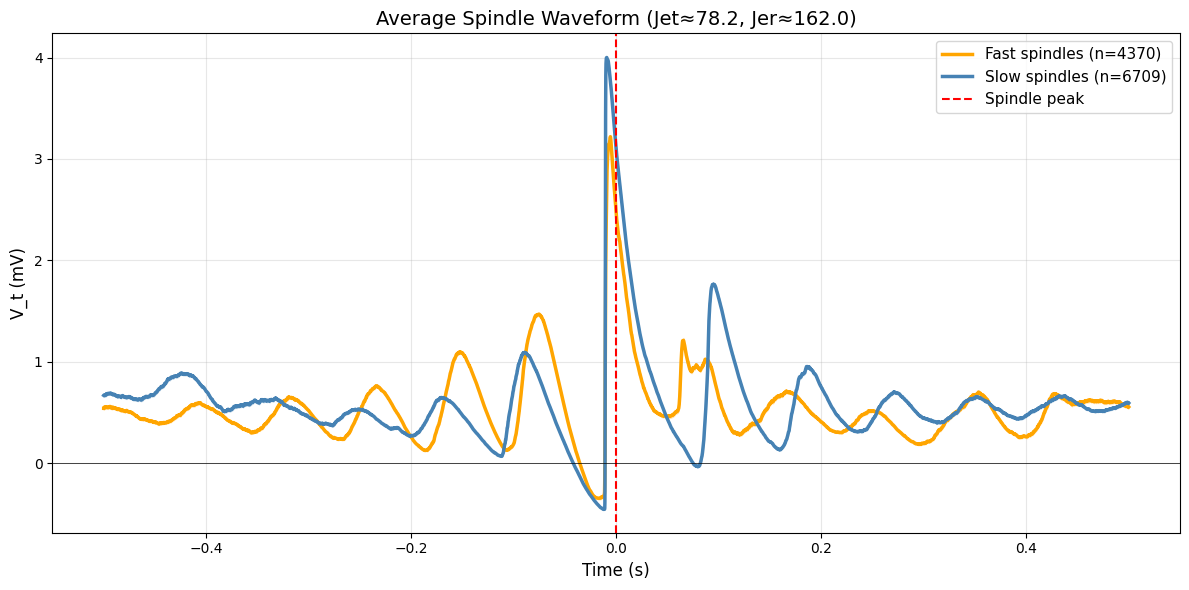

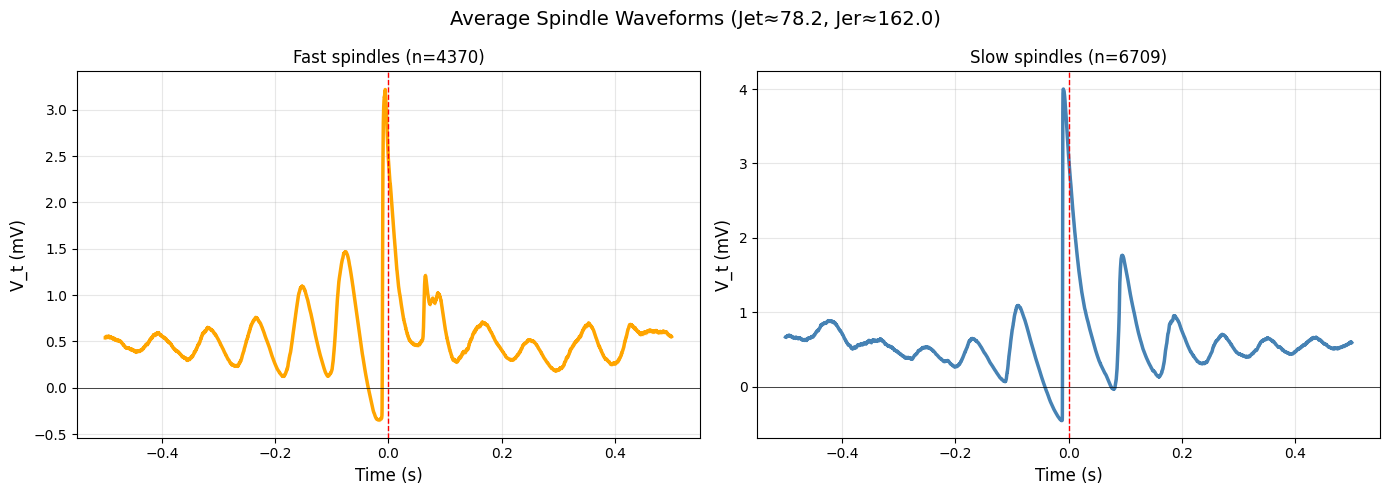

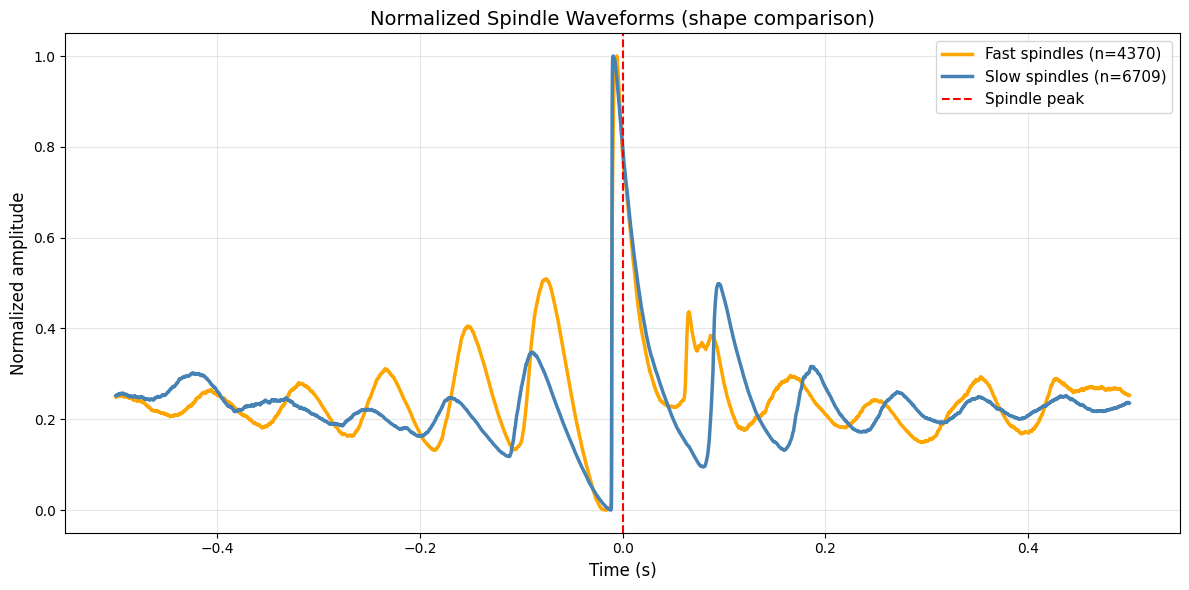

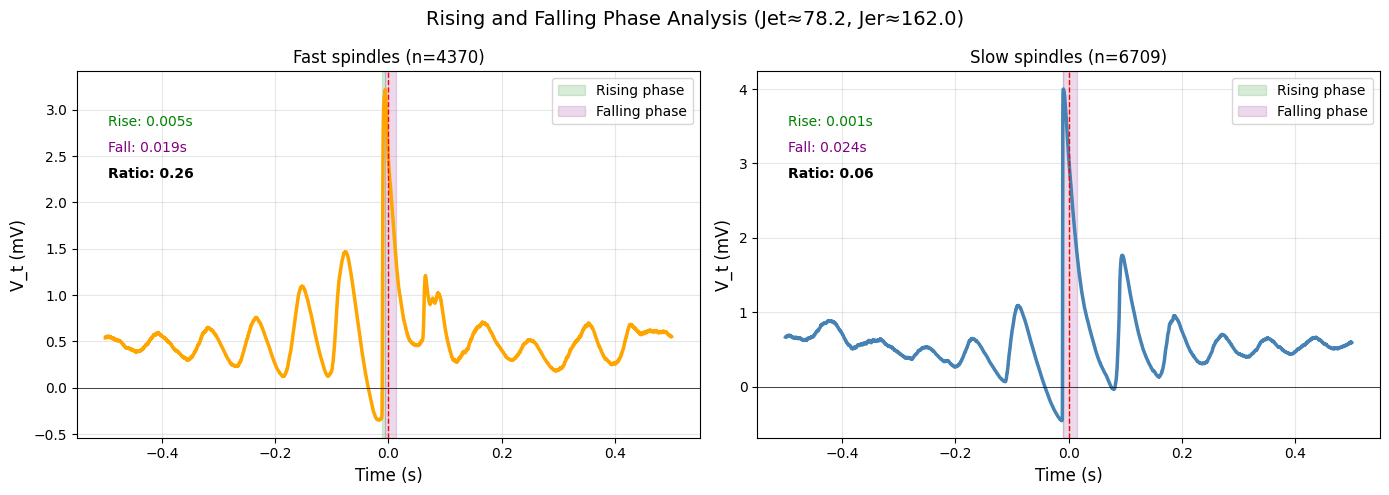

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
window_before = 0.5   # 峰值前 0.5 秒
window_after = 0.5    # 峰值后 0.5 秒
window_samples = int((window_before + window_after) * sf)

CSV_PATH = "data/analysis_data/spindles_Jet_78.2_Jer_162.0.csv"
DATA_DIR = "data/raw_data_explore_Jet_Jer_scale0x0005_Jrta_particular100"

# ========== 读取 CSV ==========
df = pd.read_csv(CSV_PATH)
print(f"读取 {len(df)} 个纺锤波")

# ========== 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    Jet_idx = parts.index('Jet') + 1 if 'Jet' in parts else -1
    Jer_idx = parts.index('Jer') + 1 if 'Jer' in parts else -1
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    if Jet_idx != -1 and Jer_idx != -1 and seed_idx != -1:
        Jet_val = float(parts[Jet_idx])
        Jer_val = float(parts[Jer_idx])
        seed = int(parts[seed_idx])
        file_map[(Jet_val, Jer_val, seed)] = file_path

print(f"文件映射: {len(file_map)} 个")

# ========== 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

# 按类型分组存储片段
fast_segments = []
slow_segments = []

for idx, row in df.iterrows():
    Jet_val = row["Jet"]
    Jer_val = row["Jer"]
    seed = row["seed"]
    peak_time = row["peak_time"]
    spindle_type = row["type"]
    
    key = (Jet_val, Jer_val, seed)
    if key not in file_map:
        continue
    
    seg = extract_segment(file_map[key], peak_time, sf, window_samples)
    if seg is not None:
        if spindle_type == 'fast':
            fast_segments.append(seg)
        else:
            slow_segments.append(seg)

print(f"快纺锤波片段: {len(fast_segments)}")
print(f"慢纺锤波片段: {len(slow_segments)}")

# ========== 计算平均波形和 SEM ==========
def compute_mean_sem(data_list):
    if len(data_list) == 0:
        return None, None
    data_array = np.array(data_list)
    mean = np.mean(data_array, axis=0)
    sem = np.std(data_array, axis=0) / np.sqrt(len(data_array))
    return mean, sem

time_axis = np.linspace(-window_before, window_after, window_samples)

fast_mean, fast_sem = compute_mean_sem(fast_segments)
slow_mean, slow_sem = compute_mean_sem(slow_segments)

# ========== 图1：快慢纺锤波平均波形叠加 ==========
fig, ax = plt.subplots(figsize=(12, 6))

if fast_mean is not None:
    ax.plot(time_axis, fast_mean, 'orange', linewidth=2.5, label=f'Fast spindles (n={len(fast_segments)})')
    ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                    color='orange', alpha=0.25)

if slow_mean is not None:
    ax.plot(time_axis, slow_mean, 'steelblue', linewidth=2.5, label=f'Slow spindles (n={len(slow_segments)})')
    ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                    color='steelblue', alpha=0.25)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Spindle peak')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('V_t (mV)', fontsize=12)
ax.set_title(f'Average Spindle Waveform (Jet≈78.2, Jer≈162.0)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图2：左右并排（快 / 慢）==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：快纺锤波
ax = axes[0]
if fast_mean is not None:
    ax.plot(time_axis, fast_mean, 'orange', linewidth=2.5)
    ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                    color='orange', alpha=0.25)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('V_t (mV)', fontsize=12)
ax.set_title(f'Fast spindles (n={len(fast_segments)})', fontsize=12)
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波
ax = axes[1]
if slow_mean is not None:
    ax.plot(time_axis, slow_mean, 'steelblue', linewidth=2.5)
    ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                    color='steelblue', alpha=0.25)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('V_t (mV)', fontsize=12)
ax.set_title(f'Slow spindles (n={len(slow_segments)})', fontsize=12)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Average Spindle Waveforms (Jet≈78.2, Jer≈162.0)', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：归一化后对比（突出形状差异）==========
fig, ax = plt.subplots(figsize=(12, 6))

if fast_mean is not None:
    # 归一化到 [0, 1] 范围
    fast_norm = (fast_mean - np.min(fast_mean)) / (np.max(fast_mean) - np.min(fast_mean))
    ax.plot(time_axis, fast_norm, 'orange', linewidth=2.5, label=f'Fast spindles (n={len(fast_segments)})')

if slow_mean is not None:
    slow_norm = (slow_mean - np.min(slow_mean)) / (np.max(slow_mean) - np.min(slow_mean))
    ax.plot(time_axis, slow_norm, 'steelblue', linewidth=2.5, label=f'Slow spindles (n={len(slow_segments)})')

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Spindle peak')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Normalized amplitude', fontsize=12)
ax.set_title(f'Normalized Spindle Waveforms (shape comparison)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图4：叠加标注上升/下降阶段 ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (spindle_type, mean, sem, color, n) in enumerate([
    ('Fast', fast_mean, fast_sem, 'orange', len(fast_segments)),
    ('Slow', slow_mean, slow_sem, 'steelblue', len(slow_segments))
]):
    ax = axes[idx]
    if mean is not None:
        ax.plot(time_axis, mean, color, linewidth=2.5)
        ax.fill_between(time_axis, mean - sem, mean + sem, color=color, alpha=0.25)
        
        # 标记上升阶段 (start→peak) 和下降阶段 (peak→end)
        # 找到峰值位置（0 附近的最大值）
        peak_idx = np.argmax(mean)
        peak_time_val = time_axis[peak_idx]
        
        # 找到 start 和 end（半高宽位置，或固定阈值）
        # 用半高宽来标记上升和下降阶段
        half_max = (np.max(mean) + np.min(mean)) / 2
        # 找上升阶段过 half_max 的点
        for i in range(peak_idx, 0, -1):
            if mean[i] <= half_max:
                start_idx = i
                break
        # 找下降阶段过 half_max 的点
        for i in range(peak_idx, len(mean)):
            if mean[i] <= half_max:
                end_idx = i
                break
        
        # 标记上升和下降阶段
        ax.axvspan(time_axis[start_idx], peak_time_val, alpha=0.15, color='green', label='Rising phase')
        ax.axvspan(peak_time_val, time_axis[end_idx], alpha=0.15, color='purple', label='Falling phase')
        
        # 标注时间
        rise_time = peak_time_val - time_axis[start_idx]
        fall_time = time_axis[end_idx] - peak_time_val
        ax.text(0.05, 0.85, f'Rise: {rise_time:.3f}s', transform=ax.transAxes, fontsize=10, color='green')
        ax.text(0.05, 0.78, f'Fall: {fall_time:.3f}s', transform=ax.transAxes, fontsize=10, color='purple')
        ax.text(0.05, 0.71, f'Ratio: {rise_time/fall_time:.2f}', transform=ax.transAxes, fontsize=10, fontweight='bold')
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('V_t (mV)', fontsize=12)
    ax.set_title(f'{spindle_type} spindles (n={n})', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Rising and Falling Phase Analysis (Jet≈78.2, Jer≈162.0)', fontsize=14)
plt.tight_layout()
plt.show()

#### Jer=162.0的情况下 未对纺锤细分的版本
- 去掉threshold 只有一个最终版本

In [ ]:
import numpy as np
import pandas as pd
import yasa
import glob
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这几行 ==========
DATA_FOLDER = "Jet_Jer_scale0x0005_Jrta_particular100"           # 数据文件夹名
PARAM1_NAME = "Jet"               # 第一个参数名
PARAM2_NAME = "Jer"               # 第二个参数名
PARAM1_RANGE = (0, 148.5)         # Jet 范围 (min, max)
PARAM2_RANGE = (0, 162)           # Jer 范围 (min, max)
# =================================

# 自动生成路径和配置
RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_CSV = f"data/analysis_data/spindles_{DATA_FOLDER}_explore.csv"

def get_phase(signal, filter_args, pad=None):
    """返回相位（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, slow_phase):
    """处理纺锤波检测结果，返回列表"""
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": slow_phase[start_idx],
            "phase_at_peak": slow_phase[peak_idx],
            "phase_at_end": slow_phase[end_idx],
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM1_NAME} 范围: {PARAM1_RANGE}")
print(f"限定 {PARAM2_NAME} 范围: {PARAM2_RANGE}")
print(f"输出文件: {OUTPUT_CSV}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 文件名格式: c2tsc_{val}_scale2_{val}_Jet_{val}_Jer_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    
    Jet_idx = parts.index(PARAM1_NAME) + 1 if PARAM1_NAME in parts else -1
    Jer_idx = parts.index(PARAM2_NAME) + 1 if PARAM2_NAME in parts else -1
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    
    if Jet_idx == -1 or Jer_idx == -1 or seed_idx == -1:
        print(f"  警告：无法解析文件名 {filename}，跳过")
        continue
    
    Jet_val = float(parts[Jet_idx])
    Jer_val = float(parts[Jer_idx])
    seed = int(parts[seed_idx])
    
    # 过滤参数范围
    if not (PARAM1_RANGE[0] <= Jet_val <= PARAM1_RANGE[1]):
        continue
    if not (PARAM2_RANGE[0] <= Jer_val <= PARAM2_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM1_NAME}={Jet_val:.4f}, {PARAM2_NAME}={Jer_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase = get_phase(aln_sig, filter_args=SW, pad=0.0)
    
    params = {
        "c2tsc": c2tsc,
        "scale2": scale2,
        PARAM1_NAME: Jet_val,
        PARAM2_NAME: Jer_val,
        "seed": seed,
    }
    
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, slow_phase))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, slow_phase))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"快纺锤波: {len(result_df[result_df['type'] == 'fast'])}")
print(f"慢纺锤波: {len(result_df[result_df['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# 打印参数范围
print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.6f} ~ {result_df['scale2'].max():.6f}")
print(f"  Jet: {result_df['Jet'].min():.4f} ~ {result_df['Jet'].max():.4f}")
print(f"  Jer: {result_df['Jer'].min():.4f} ~ {result_df['Jer'].max():.4f}")

print("\n前几行:")
print(result_df.head())

d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


找到 1400 个文件
限定 Jet 范围: (0, 148.5)
限定 Jer 范围: (0, 162)
输出文件: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_particular100_explore.csv
Processing: Jet=107.7360, Jer=162.0000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=4, 慢=9
Processing: Jet=107.7360, Jer=162.0000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

...

  完成：快=3, 慢=9
Processing: Jet=91.7653, Jer=162.0000, seed=98
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=5, 慢=9
Processing: Jet=91.7653, Jer=162.0000, seed=99
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=5, 慢=6

总共检测到 15011 个纺锤波
快纺锤波: 5557
慢纺锤波: 9454
CSV 已保存: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_particular100_explore.csv

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.000500 ~ 0.000500
  Jet: 78.1620 ~ 148.5000
  Jer: 162.0000 ~ 162.0000

前几行:
   c2tsc  scale2      Jet    Jer  seed  type    start  peak_time      end  \
0    0.8  0.0005  107.736  162.0     1  fast  14.0423    14.4431  14.7950   
1    0.8  0.0005  107.736  162.0     1  fast  16.3620    16.5024  17.1605   
2    0.8  0.0005  107.736  162.0     1  fast  26.5569    26.5969  26.8953   
3    0.8  0.0005  107.736  162.0     1  slow   2.6806     2.8919   3.0397   
4    0.8  0.0005  107.736  162.0     1  slow   4.0478     4.5406   4.6329   

   duration  frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  
0    0.7527  12.912147   3.313219       -2.881803      -1.757782     -1.308409  
1    0.7985  13.626042   3.004060        2.850816      -3.020375     -1.590281  
2    0.3384  12.954672   2.4863

#### Jer=162.0 各个Jet运行100次的情况下画图

总纺锤波数: 15011
Jet 范围: 78.16 ~ 148.50
Jer 范围: 162.00 ~ 162.00

使用的 Jet 值: [78.162, 91.7653, 107.736, 126.4864, 148.5]
使用的 Jer 值: [162.0]

原始有效参数组合数: 5
过滤后有效参数组合数: 5


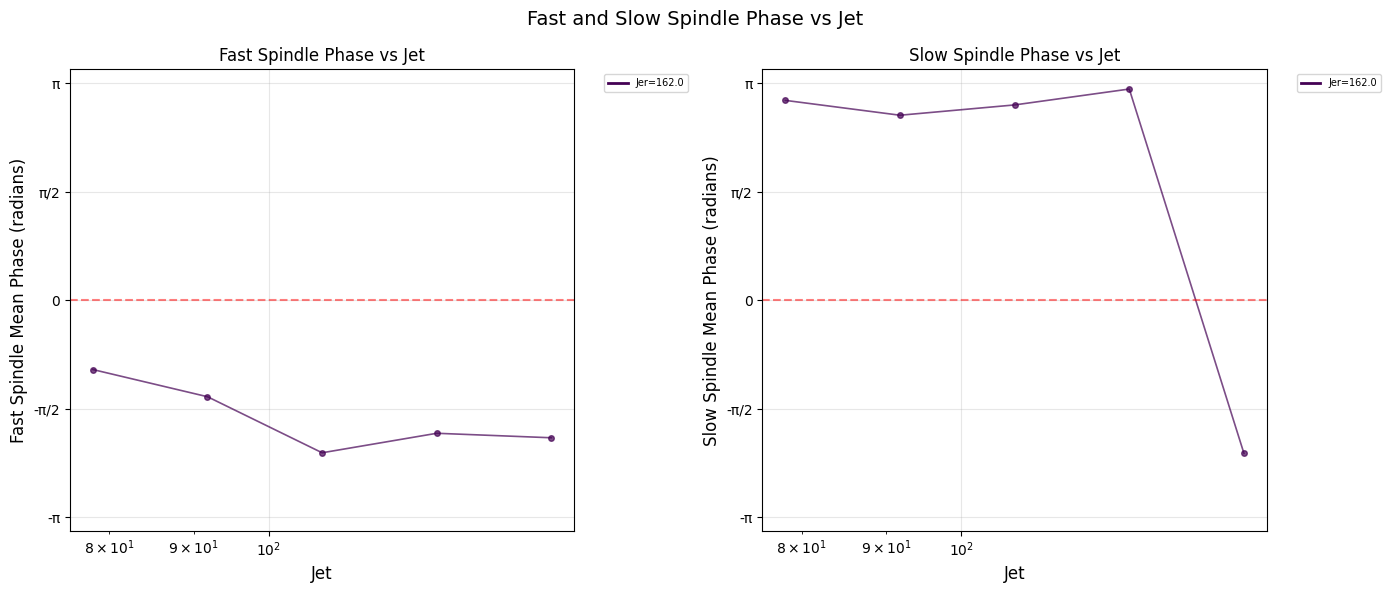

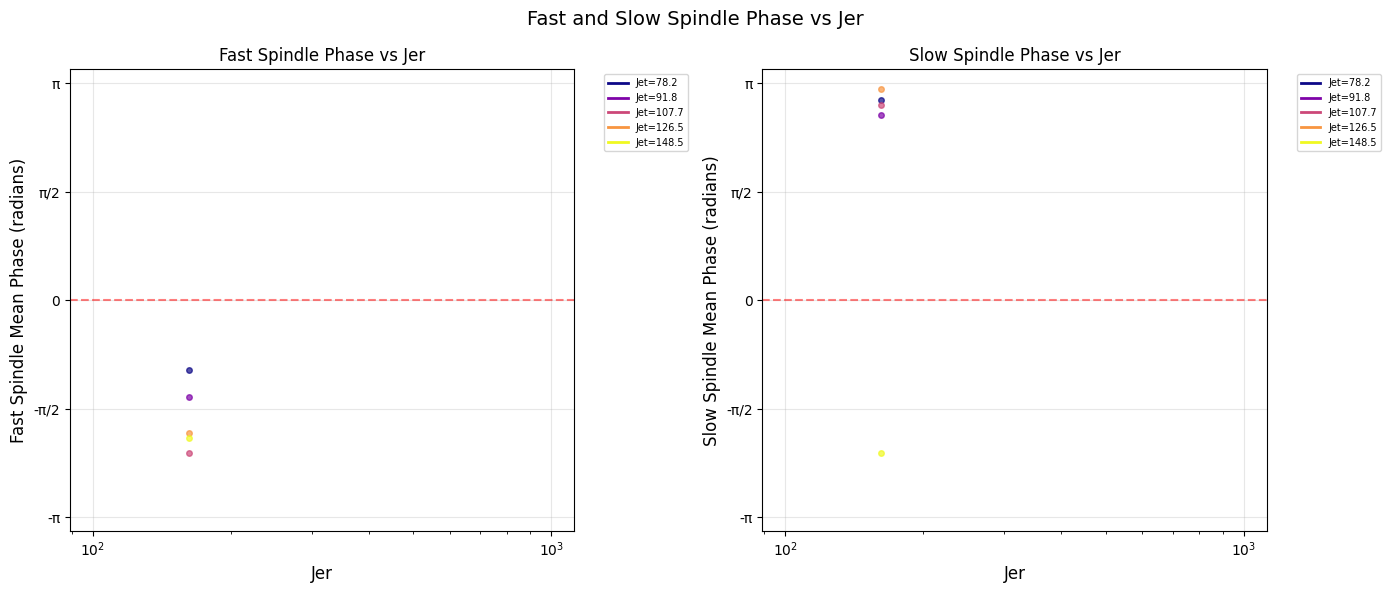

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_particular100_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 和 Jer 值 ==========
Jet_values_all = sorted(df['Jet'].unique())
Jer_values_all = sorted(df['Jer'].unique())

# 去掉你不想显示的值（修改这里即可）
Jet_values_all = Jet_values_all#[:-1]  # 去掉最后一个（最大值）
Jer_values_all = Jer_values_all#[:-1]  # 去掉最后一个（最大值）

print(f"\n使用的 Jet 值: {Jet_values_all}")
print(f"使用的 Jer 值: {Jer_values_all}")

# ========== 计算每个 (Jet, Jer) 组合下快慢纺锤波的相位 ==========
fast_phase = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_phase')

slow_phase = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_phase')

fast_std = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_std')

slow_std = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_std')

# 合并
phase_df = pd.merge(fast_phase, slow_phase, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, fast_std, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, slow_std, on=['Jet', 'Jer'])
phase_df['phase_diff'] = phase_df['fast_phase'] - phase_df['slow_phase']
phase_df = phase_df.dropna()

# ========== 关键：用 Jet_values_all 和 Jer_values_all 过滤 phase_df ==========
phase_df_filtered = phase_df[
    (phase_df['Jet'].isin(Jet_values_all)) & 
    (phase_df['Jer'].isin(Jer_values_all))
].copy()

print(f"\n原始有效参数组合数: {len(phase_df)}")
print(f"过滤后有效参数组合数: {len(phase_df_filtered)}")

# ========== 图2：快慢纺锤波各自的相位 vs Jet ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jer_values_all)))

# 左图：快纺锤波相位 vs Jet
ax = axes[0]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['fast_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Jer={Jer_values_all[i]:.1f}') 
                   for i in range(0, len(Jer_values_all), max(1, len(Jer_values_all)//5))]
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jet
ax = axes[1]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['slow_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jet', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢纺锤波各自的相位 vs Jer ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors2 = plt.cm.plasma(np.linspace(0, 1, len(Jet_values_all)))

# 左图：快纺锤波相位 vs Jer
ax = axes[0]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['fast_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

legend_elements2 = [Line2D([0], [0], color=colors2[i], lw=2, label=f'Jet={Jet_values_all[i]:.1f}') 
                    for i in range(0, len(Jet_values_all), max(1, len(Jet_values_all)//5))]
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jer
ax = axes[1]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['slow_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jer', fontsize=14)
plt.tight_layout()
plt.show()

### 以下的csv名称未改

总纺锤波数: 52603
Jet 范围: 6.50 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jer: 162, 实际最近值: 162.0000


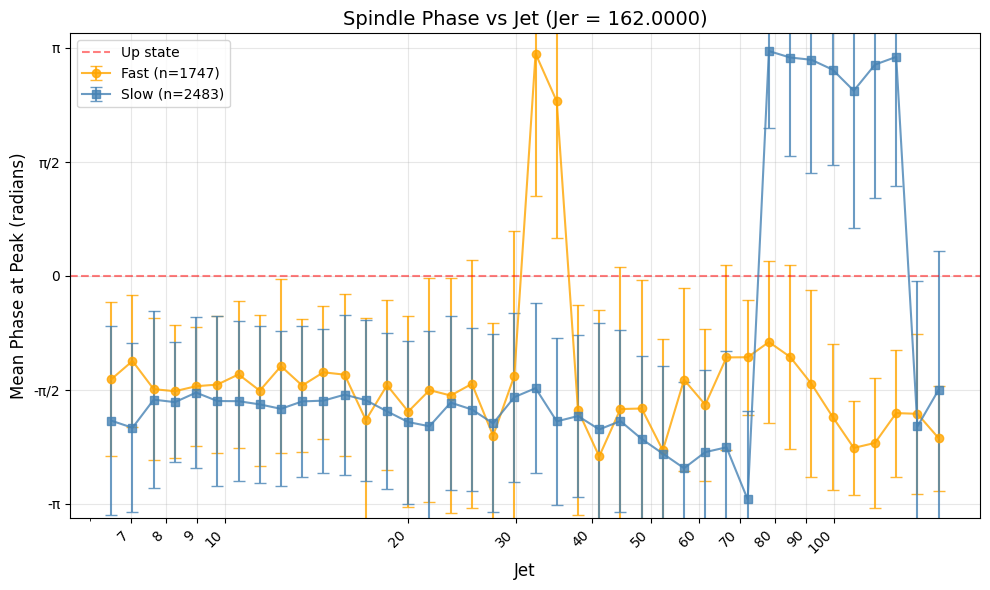


统计摘要 (Jer = 162.0000)
Jet=6.5000: Fast mean=-1.427±1.065 rad (n=58) Slow mean=-1.997±1.298 rad (n=60)
Jet=7.0430: Fast mean=-1.175±0.916 rad (n=51) Slow mean=-2.095±1.162 rad (n=58)
Jet=7.6313: Fast mean=-1.563±0.974 rad (n=62) Slow mean=-1.708±1.225 rad (n=60)
Jet=8.2687: Fast mean=-1.591±0.915 rad (n=46) Slow mean=-1.742±0.830 rad (n=55)
Jet=8.9594: Fast mean=-1.523±0.819 rad (n=47) Slow mean=-1.610±1.040 rad (n=49)
Jet=9.7078: Fast mean=-1.500±0.948 rad (n=52) Slow mean=-1.727±1.178 rad (n=58)
Jet=10.5187: Fast mean=-1.360±1.018 rad (n=38) Slow mean=-1.729±1.101 rad (n=64)
Jet=11.3973: Fast mean=-1.584±1.037 rad (n=57) Slow mean=-1.773±1.078 rad (n=60)
Jet=12.3494: Fast mean=-1.247±1.197 rad (n=50) Slow mean=-1.834±1.067 rad (n=61)
Jet=13.3809: Fast mean=-1.513±0.921 rad (n=50) Slow mean=-1.732±1.036 rad (n=61)
Jet=14.4986: Fast mean=-1.331±0.919 rad (n=51) Slow mean=-1.722±0.991 rad (n=58)
Jet=15.7097: Fast mean=-1.363±1.118 rad (n=47) Slow mean=-1.639±1.104 rad (n=63)
Jet=17.0220

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========

df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv")


# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 值 ==========
Jet_values = sorted(df['Jet'].unique())

# ========== 找到最接近 71.3 的 Jer 值 ==========
target_Jer = 162
all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 计算该 Jer 下每个 Jet 的快慢纺锤波相位 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

fast_means = []
fast_stds = []
slow_means = []
slow_stds = []
fast_ns = []
slow_ns = []
jet_vals = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    # 快纺锤波
    fast_phases = subset[subset['type'] == 'fast']['phase_at_peak'].dropna().values
    if len(fast_phases) > 0:
        m, s = circular_stats(fast_phases)
        fast_means.append(m)
        fast_stds.append(s)
        fast_ns.append(len(fast_phases))
    else:
        fast_means.append(np.nan)
        fast_stds.append(np.nan)
        fast_ns.append(0)
    
    # 慢纺锤波
    slow_phases = subset[subset['type'] == 'slow']['phase_at_peak'].dropna().values
    if len(slow_phases) > 0:
        m, s = circular_stats(slow_phases)
        slow_means.append(m)
        slow_stds.append(s)
        slow_ns.append(len(slow_phases))
    else:
        slow_means.append(np.nan)
        slow_stds.append(np.nan)
        slow_ns.append(0)
    
    jet_vals.append(jet_val)

jet_vals = np.array(jet_vals)
fast_means = np.array(fast_means)
fast_stds = np.array(fast_stds)
slow_means = np.array(slow_means)
slow_stds = np.array(slow_stds)

valid_fast = ~np.isnan(fast_means)
valid_slow = ~np.isnan(slow_means)

# ========== 画图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

# 快纺锤波（带误差棒）
if np.any(valid_fast):
    ax.errorbar(jet_vals[valid_fast], fast_means[valid_fast], 
                yerr=fast_stds[valid_fast],
                fmt='o-', color='orange', capsize=4, 
                label=f'Fast (n={sum(fast_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

# 慢纺锤波（带误差棒）
if np.any(valid_slow):
    ax.errorbar(jet_vals[valid_slow], slow_means[valid_slow], 
                yerr=slow_stds[valid_slow],
                fmt='s-', color='steelblue', capsize=4, 
                label=f'Slow (n={sum(slow_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Mean Phase at Peak (radians)', fontsize=12)
ax.set_title(f'Spindle Phase vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xscale('log')

# ========== 设置更细致的横坐标刻度 ==========
# 生成从 1 到 200 的刻度值（对数坐标下均匀分布）
xticks_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
# 只保留在 Jet 范围内的刻度
xticks_values = [v for v in xticks_values if v >= min(jet_vals) and v <= max(jet_vals)]
# 如果最小 Jet 小于 1，添加 0.1 和 0.5
if min(jet_vals) < 1:
    xticks_values = [0.1, 0.5] + xticks_values
ax.set_xticks(xticks_values)
ax.set_xticklabels([str(v) for v in xticks_values], rotation=45, ha='right')

ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Up state')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)

for jet, fm, fs, sm, ss, fn, sn in zip(jet_vals, fast_means, fast_stds, slow_means, slow_stds, fast_ns, slow_ns):
    if not np.isnan(fm) or not np.isnan(sm):
        line = f"Jet={jet:.4f}:"
        if not np.isnan(fm):
            line += f" Fast mean={fm:.3f}±{fs:.3f} rad (n={fn})"
        if not np.isnan(sm):
            line += f" Slow mean={sm:.3f}±{ss:.3f} rad (n={sn})"
        print(line)

总纺锤波数: 52603
Jet 范围: 6.50 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jer: 162, 实际最近值: 162.0000


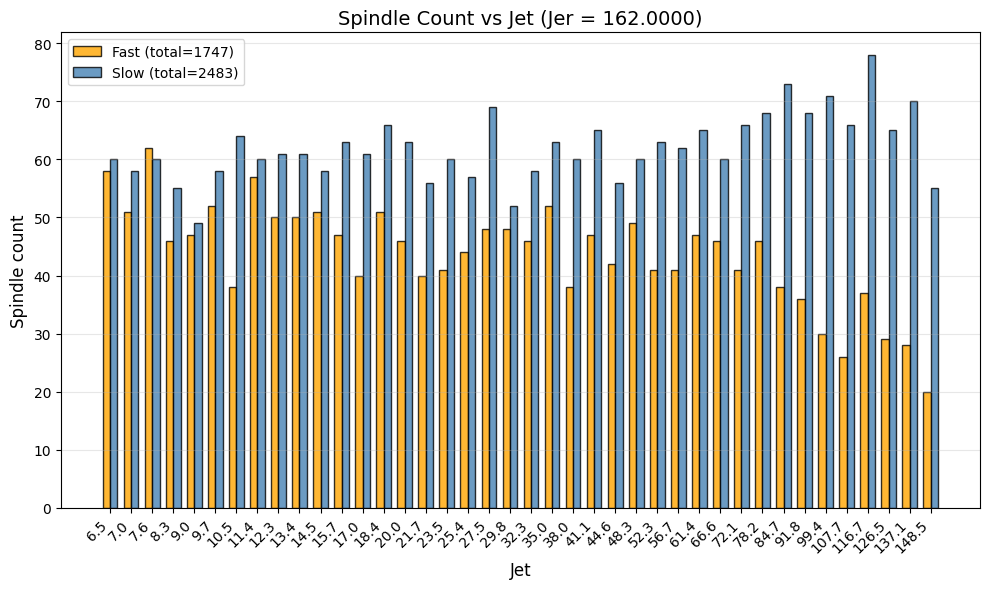


统计摘要 (Jer = 162.0000)
       Jet     Fast     Slow    Total
--------------------------------------
       6.5       58       60      118
       7.0       51       58      109
       7.6       62       60      122
       8.3       46       55      101
       9.0       47       49       96
       9.7       52       58      110
      10.5       38       64      102
      11.4       57       60      117
      12.3       50       61      111
      13.4       50       61      111
      14.5       51       58      109
      15.7       47       63      110
      17.0       40       61      101
      18.4       51       66      117
      20.0       46       63      109
      21.7       40       56       96
      23.5       41       60      101
      25.4       44       57      101
      27.5       48       69      117
      29.8       48       52      100
      32.3       46       58      104
      35.0       52       63      115
      38.0       38       60       98
      41.1       47       

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近 71.3 的 Jer 值 ==========

all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选该 Jer 下的数据 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

# ========== 统计每个 Jet 下的快慢纺锤波个数 ==========
jet_vals = []
fast_counts = []
slow_counts = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    
    jet_vals.append(jet_val)
    fast_counts.append(fast_count)
    slow_counts.append(slow_count)

jet_vals = np.array(jet_vals)
fast_counts = np.array(fast_counts)
slow_counts = np.array(slow_counts)

# ========== 画图：快慢纺锤波个数随 Jet 变化 ==========
fig, ax = plt.subplots(figsize=(10, 6))

width = 0.35
x = np.arange(len(jet_vals))

ax.bar(x - width/2, fast_counts, width, color='orange', edgecolor='black', 
       label=f'Fast (total={sum(fast_counts)})', alpha=0.8)
ax.bar(x + width/2, slow_counts, width, color='steelblue', edgecolor='black', 
       label=f'Slow (total={sum(slow_counts)})', alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Spindle count', fontsize=12)
ax.set_title(f'Spindle Count vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.1f}' for v in jet_vals], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)
print(f"{'Jet':>10} {'Fast':>8} {'Slow':>8} {'Total':>8}")
print("-"*38)
for j, fc, sc in zip(jet_vals, fast_counts, slow_counts):
    print(f"{j:>10.1f} {fc:>8} {sc:>8} {fc+sc:>8}")
print("-"*38)
print(f"{'Total':>10} {sum(fast_counts):>8} {sum(slow_counts):>8} {sum(fast_counts)+sum(slow_counts):>8}")

总纺锤波数: 15011
Jet 范围: 78.16 ~ 148.50
Jer 范围: 162.00 ~ 162.00

目标 Jet: 148, 实际最近值: 148.5000
目标 Jer: 162, 实际最近值: 162.0000

筛选后的纺锤波总数: 802
快纺锤波: 207
慢纺锤波: 595
包含的 seed: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]

快纺锤波 phase_at_peak 数量: 207
慢纺锤波 phase_at_peak 数量: 595


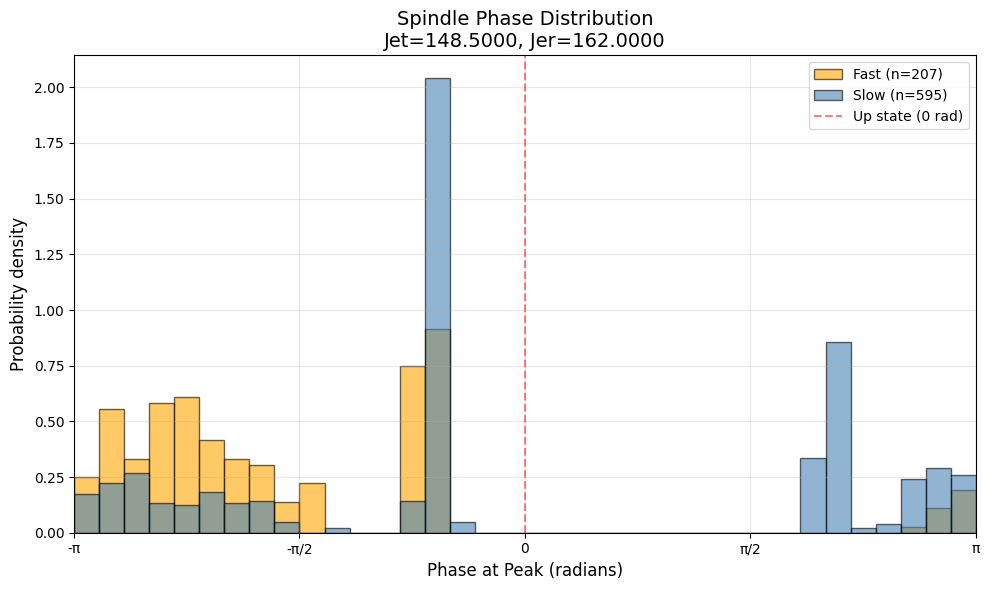

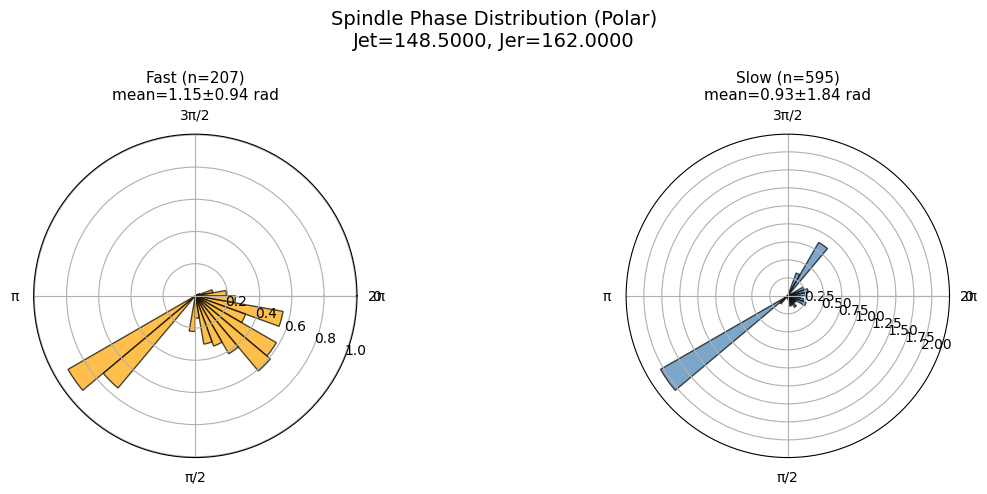

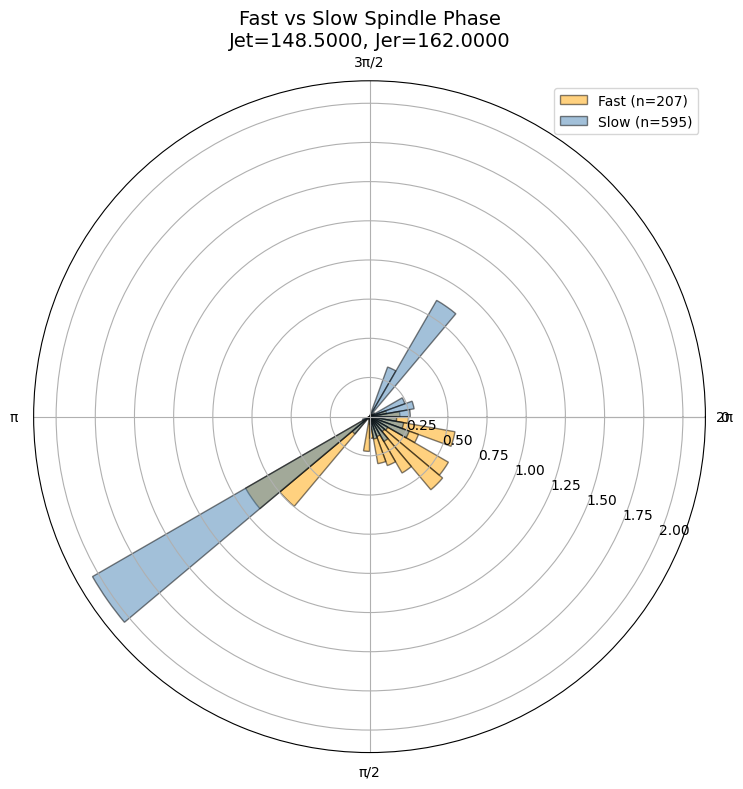


统计摘要
Fast: n=207, mean=-1.991 rad, std=0.943 rad
Slow: n=595, mean=-2.216 rad, std=1.838 rad


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_particular100_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近的目标值 ==========
target_Jet = 148
target_Jer = 162

all_Jet_values = sorted(df['Jet'].unique())
all_Jer_values = sorted(df['Jer'].unique())

closest_Jet = min(all_Jet_values, key=lambda x: abs(x - target_Jet))
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))

print(f"\n目标 Jet: {target_Jet}, 实际最近值: {closest_Jet:.4f}")
print(f"目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选目标参数 ==========
df_filtered = df[(np.abs(df['Jet'] - closest_Jet) < 1e-6) & 
                 (np.abs(df['Jer'] - closest_Jer) < 1e-6)]

print(f"\n筛选后的纺锤波总数: {len(df_filtered)}")
print(f"快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")

# 显示有哪些 seed
seeds = sorted(df_filtered['seed'].unique())
print(f"包含的 seed: {seeds}")

# ========== 提取 phase_at_peak ==========
fast_phases = df_filtered[df_filtered['type'] == 'fast']['phase_at_peak'].dropna().values
slow_phases = df_filtered[df_filtered['type'] == 'slow']['phase_at_peak'].dropna().values

print(f"\n快纺锤波 phase_at_peak 数量: {len(fast_phases)}")
print(f"慢纺锤波 phase_at_peak 数量: {len(slow_phases)}")

# ========== 将相位从 -π~π 转换到 0~2π ==========
def phase_to_0_2pi(phases):
    return (phases + np.pi) % (2 * np.pi)

fast_phases_0_2pi = phase_to_0_2pi(fast_phases) if len(fast_phases) > 0 else np.array([])
slow_phases_0_2pi = phase_to_0_2pi(slow_phases) if len(slow_phases) > 0 else np.array([])

# ========== 图1：线性直方图（叠加对比）==========
fig, ax = plt.subplots(figsize=(10, 6))

if len(fast_phases) > 0:
    ax.hist(fast_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='orange', edgecolor='black', density=True, 
            label=f'Fast (n={len(fast_phases)})')
if len(slow_phases) > 0:
    ax.hist(slow_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='steelblue', edgecolor='black', density=True, 
            label=f'Slow (n={len(slow_phases)})')

ax.set_xlabel('Phase at Peak (radians)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Spindle Phase Distribution\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Up state (0 rad)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图2：极坐标直方图（左右并排）==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})

n_bins = 36
bins = np.linspace(0, 2*np.pi, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
width = 2 * np.pi / n_bins

for idx, (phases, label, color) in enumerate([
    (fast_phases_0_2pi, f'Fast (n={len(fast_phases)})', 'orange'),
    (slow_phases_0_2pi, f'Slow (n={len(slow_phases)})', 'steelblue')
]):
    ax = axes[idx]
    if len(phases) > 0:
        hist, _ = np.histogram(phases, bins=bins, density=True)
        ax.bar(bin_centers, hist, width=width, color=color, edgecolor='black', alpha=0.7)
        mean_p = circmean(phases, low=0, high=2*np.pi)
        std_p = circstd(phases, low=0, high=2*np.pi)
        ax.set_title(f'{label}\nmean={mean_p:.2f}±{std_p:.2f} rad', fontsize=11)
        ax.set_ylim(0, max(hist) * 1.1 if len(hist) > 0 else 0.6)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title(label, fontsize=11)
        ax.set_ylim(0, 0.6)
    
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

plt.suptitle(f'Spindle Phase Distribution (Polar)\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢叠加在同一极坐标图上 ==========
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

if len(fast_phases_0_2pi) > 0:
    hist_fast, _ = np.histogram(fast_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_fast, width=width, color='orange', edgecolor='black', 
           alpha=0.5, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases_0_2pi) > 0:
    hist_slow, _ = np.histogram(slow_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_slow, width=width, color='steelblue', edgecolor='black', 
           alpha=0.5, label=f'Slow (n={len(slow_phases)})')

ax.set_title(f'Fast vs Slow Spindle Phase\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for name, phases in [('Fast', fast_phases), ('Slow', slow_phases)]:
    if len(phases) > 0:
        mean_p = circmean(phases, low=-np.pi, high=np.pi)
        std_p = circstd(phases, low=-np.pi, high=np.pi)
        print(f"{name}: n={len(phases)}, mean={mean_p:.3f} rad, std={std_p:.3f} rad")
    else:
        print(f"{name}: 无数据")

总纺锤波数: 15011
Jet 范围: 78.16 ~ 148.50
Jer 范围: 162.00 ~ 162.00

目标 Jet: 80, 实际最近值: 78.1620
目标 Jer: 162, 实际最近值: 162.0000

筛选后的纺锤波总数: 11079
快纺锤波: 4370
慢纺锤波: 6709
包含的 seed: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 

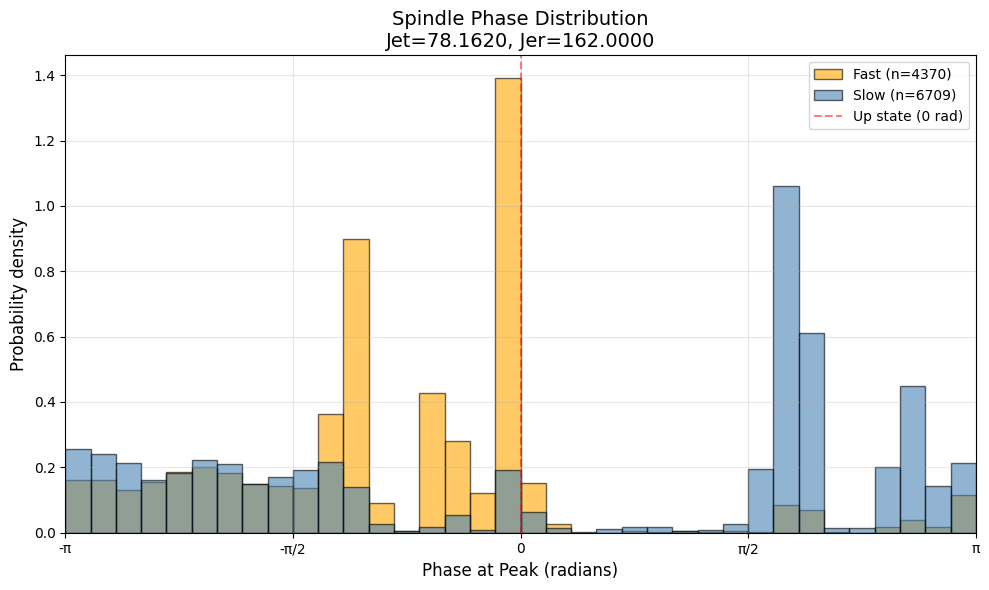

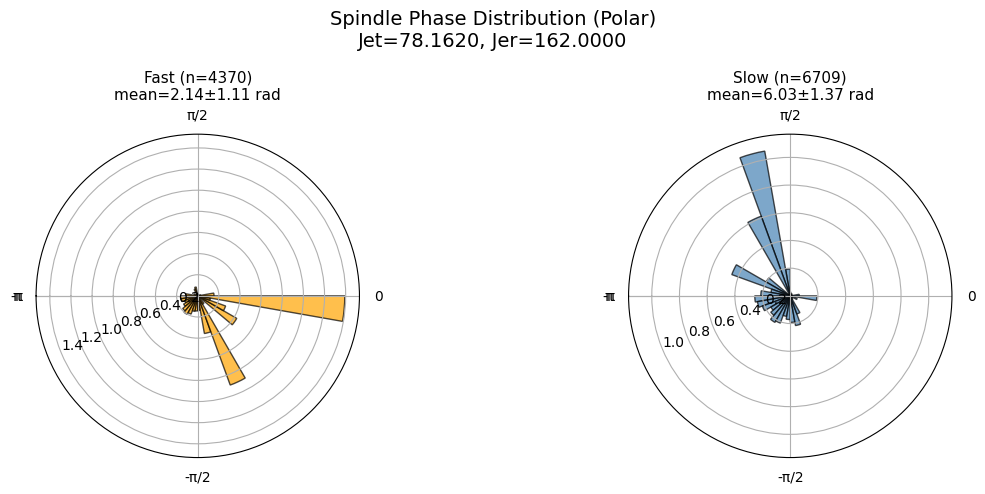

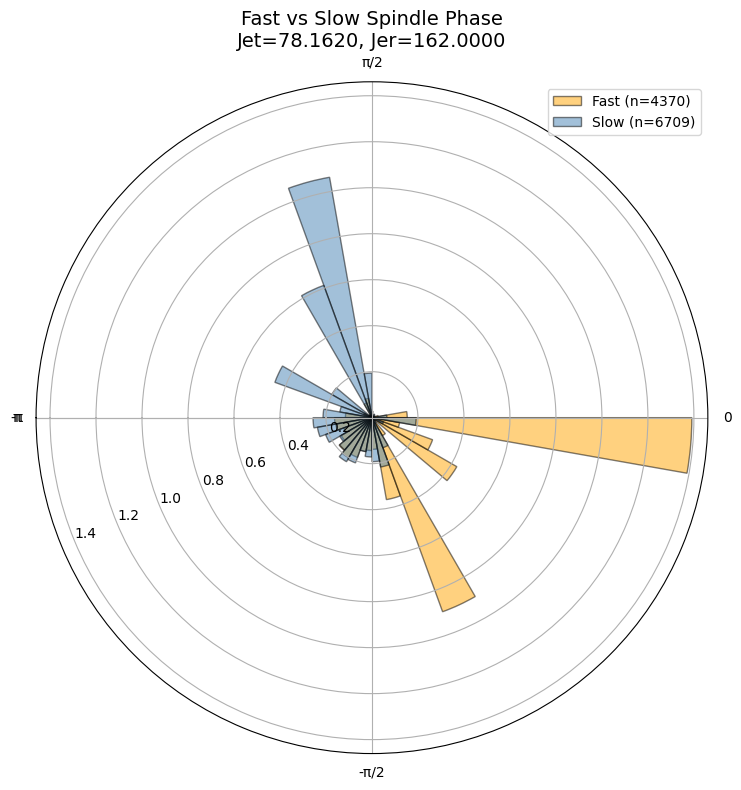


统计摘要
Fast: n=4370, mean=-1.003 rad, std=1.110 rad
Slow: n=6709, mean=2.892 rad, std=1.370 rad


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_particular100_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近的目标值 ==========
target_Jet = 80
target_Jer = 162

all_Jet_values = sorted(df['Jet'].unique())
all_Jer_values = sorted(df['Jer'].unique())

closest_Jet = min(all_Jet_values, key=lambda x: abs(x - target_Jet))
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))

print(f"\n目标 Jet: {target_Jet}, 实际最近值: {closest_Jet:.4f}")
print(f"目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选目标参数 ==========
df_filtered = df[(np.abs(df['Jet'] - closest_Jet) < 1e-6) & 
                 (np.abs(df['Jer'] - closest_Jer) < 1e-6)]

print(f"\n筛选后的纺锤波总数: {len(df_filtered)}")
print(f"快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")

seeds = sorted(df_filtered['seed'].unique())
print(f"包含的 seed: {seeds}")

# ========== 提取 phase_at_peak ==========
fast_phases = df_filtered[df_filtered['type'] == 'fast']['phase_at_peak'].dropna().values
slow_phases = df_filtered[df_filtered['type'] == 'slow']['phase_at_peak'].dropna().values

print(f"\n快纺锤波 phase_at_peak 数量: {len(fast_phases)}")
print(f"慢纺锤波 phase_at_peak 数量: {len(slow_phases)}")

# ========== 将相位从 -π~π 转换到 0~2π ==========
def phase_to_0_2pi(phases):
    return (phases + np.pi) % (2 * np.pi)

fast_phases_0_2pi = phase_to_0_2pi(fast_phases) if len(fast_phases) > 0 else np.array([])
slow_phases_0_2pi = phase_to_0_2pi(slow_phases) if len(slow_phases) > 0 else np.array([])

# ========== 图1：线性直方图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

if len(fast_phases) > 0:
    ax.hist(fast_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='orange', edgecolor='black', density=True, 
            label=f'Fast (n={len(fast_phases)})')
if len(slow_phases) > 0:
    ax.hist(slow_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='steelblue', edgecolor='black', density=True, 
            label=f'Slow (n={len(slow_phases)})')

ax.set_xlabel('Phase at Peak (radians)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Spindle Phase Distribution\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Up state (0 rad)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图2：极坐标直方图（左右并排）==========
# 正确的设置：
# - 0° 在左侧（正西），对应 -π
# - 逆时针方向，对应 -π → π
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})

n_bins = 36
bins = np.linspace(0, 2*np.pi, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
width = 2 * np.pi / n_bins

for idx, (phases, label, color) in enumerate([
    (fast_phases_0_2pi, f'Fast (n={len(fast_phases)})', 'orange'),
    (slow_phases_0_2pi, f'Slow (n={len(slow_phases)})', 'steelblue')
]):
    ax = axes[idx]
    if len(phases) > 0:
        hist, _ = np.histogram(phases, bins=bins, density=True)
        ax.bar(bin_centers, hist, width=width, color=color, edgecolor='black', alpha=0.7)
        mean_p = circmean(phases, low=0, high=2*np.pi)
        std_p = circstd(phases, low=0, high=2*np.pi)
        ax.set_title(f'{label}\nmean={mean_p:.2f}±{std_p:.2f} rad', fontsize=11)
        ax.set_ylim(0, max(hist) * 1.1 if len(hist) > 0 else 0.6)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title(label, fontsize=11)
        ax.set_ylim(0, 0.6)
    
    # ===== 关键设置：符合你的要求 =====
    # 0° 在左侧（正西），对应 -π
    ax.set_theta_zero_location('W')
    # 逆时针方向
    ax.set_theta_direction(1)
    
    # ===== 设置刻度标签 =====
    # 极坐标 0° → 左侧 → 显示 "-π"
    # 极坐标 90° → 上方 → 显示 "-π/2"
    # 极坐标 180° → 右侧 → 显示 "0"
    # 极坐标 270° → 下方 → 显示 "π/2"
    # 极坐标 360° → 左侧 → 显示 "π"
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])

plt.suptitle(f'Spindle Phase Distribution (Polar)\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢叠加在同一极坐标图上 ==========
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

if len(fast_phases_0_2pi) > 0:
    hist_fast, _ = np.histogram(fast_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_fast, width=width, color='orange', edgecolor='black', 
           alpha=0.5, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases_0_2pi) > 0:
    hist_slow, _ = np.histogram(slow_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_slow, width=width, color='steelblue', edgecolor='black', 
           alpha=0.5, label=f'Slow (n={len(slow_phases)})')

ax.set_title(f'Fast vs Slow Spindle Phase\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_theta_zero_location('W')
ax.set_theta_direction(1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for name, phases in [('Fast', fast_phases), ('Slow', slow_phases)]:
    if len(phases) > 0:
        mean_p = circmean(phases, low=-np.pi, high=np.pi)
        std_p = circstd(phases, low=-np.pi, high=np.pi)
        print(f"{name}: n={len(phases)}, mean={mean_p:.3f} rad, std={std_p:.3f} rad")
    else:
        print(f"{name}: 无数据")